"Factores que influyen en el rendimiento estudiantil"



 Este proyecto tiene como propósito analizar los factores que influyen en el rendimiento académico de estudiantes de nivel secundario. El eje central del estudio es la variable Exam_Score, considerada como indicador del desempeño escolar, y cómo se relaciona con variables individuales, familiares y contextuales. La motivación principal es comprender de manera más profunda qué elementos favorecen o dificultan el aprendizaje, con el fin de orientar estrategias pedagógicas, apoyar la toma de decisiones educativas y aportar información útil a padres y docentes.

El dataset integra variables numéricas y categóricas que abarcan distintos ámbitos de la vida estudiantil. Entre las individuales se encuentran horas de estudio, horas de sueño, asistencia y sesiones de tutoría. El entorno familiar está representado por el nivel educativo de los padres, el ingreso familiar y el apoyo brindado. A nivel contextual, se incluyen la distancia desde el hogar hasta el colegio y la participación en actividades extracurriculares como deportes, música o voluntariado. Esta diversidad de factores lo convierte en un recurso valioso para explorar tanto asociaciones directas como interacciones entre variables.

El análisis exploratorio de datos (EDA) se estructurará en varias etapas. Primero, se llevará a cabo un diagnóstico de calidad del dataset, identificando valores faltantes, duplicados o inconsistencias. Luego, se aplicarán visualizaciones univariadas, bivariadas y multivariadas, acompañadas de resúmenes estadísticos, que permitan interpretar patrones, correlaciones y posibles efectos combinados entre las variables.

Las preguntas de investigación que guían este trabajo incluyen: ¿cómo se relacionan las horas de estudio, la asistencia y la tutoría con el desempeño académico? ¿De qué manera influyen el apoyo familiar y el nivel educativo parental? ¿Existen interacciones significativas entre factores socioeconómicos y hábitos de estudio?

En esta primera fase, el objetivo es generar una base sólida de análisis descriptivo y visual que permita evaluar hipótesis iniciales y preparar el camino para futuros modelos predictivos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

ruta="/content/drive/MyDrive/Entrega n1/StudentPerformanceFactors.csv"

df=pd.read_csv(ruta)

print(df)

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
0                     

In [3]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [4]:
df.isna().sum().sum()

np.int64(235)

In [5]:
df['Parental_Education_Level'].isna().mean()

np.float64(0.013621916149538369)

In [6]:
df['Distance_from_Home'].isna().mean()

np.float64(0.010140759800211896)

In [7]:
print("Duplicados encontrados:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicados encontrados: 0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [9]:
print("Duplicados:", df.duplicated().sum())
print("Nulos totales:", df.isnull().sum().sum())
df.info()

Duplicados: 0
Nulos totales: 235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence 

In [10]:
print("Teacher_Quality:", df['Teacher_Quality'].unique())
print("Parental_Education_Level:", df['Parental_Education_Level'].unique())
print("Distance_from_Home:", df['Distance_from_Home'].unique())

Teacher_Quality: ['Medium' 'High' 'Low' nan]
Parental_Education_Level: ['High School' 'College' 'Postgraduate' nan]
Distance_from_Home: ['Near' 'Moderate' 'Far' nan]


In [11]:
df['Teacher_Quality'] = df['Teacher_Quality'].str.strip().str.lower()
df['Parental_Education_Level'] = df['Parental_Education_Level'].str.strip().str.lower()
df['Distance_from_Home'] = df['Distance_from_Home'].str.strip().str.lower()

In [12]:
print(df.isna().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [13]:
df = df[(df['Sleep_Hours'] >= 3) & (df['Sleep_Hours'] <= 12)]

In [14]:
print("Nulos totales:", df.isnull().sum().sum())

Nulos totales: 235


In [15]:
print(df.isna().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [16]:
df = df.reset_index(drop=True)

In [17]:
df.shape

(6607, 20)

El dataset Student Performance Factors cuenta con 20 variables que abarcan aspectos académicos, familiares y personales de los estudiantes. A continuación se describe cada una de ellas de manera breve:  

- Hours_Studied: número de horas de estudio semanales.  
- Attendance: porcentaje o cantidad de asistencia a clases.  
- Parental_Involvement: nivel de involucramiento de los padres en la educación (alto, medio, bajo)
- Access_to_Resources: acceso del estudiante a recursos educativos (bueno, regular, limitado).  
- Extracurricular_Activities: participación en actividades extracurriculares.  
- Sleep_Hours: horas promedio de sueño por noche.  
- Previous_Scores: puntajes obtenidos en exámenes anteriores.  
- Motivation_Level: nivel de motivación percibida (alto, medio, bajo).  
- Internet_Access: disponibilidad de Internet en el hogar.  
- Tutoring_Sessions: número de sesiones de tutoría a las que asiste el estudiante.  
- Family_Income: nivel de ingresos familiares (bajo, medio, alto).  
- Teacher_Quality: percepción de la calidad docente (alta, media, baja).  
- School_Type: tipo de escuela (pública o privada).  
- Peer_Influence: influencia de los pares (positiva, negativa, neutra).  
- Physical_Activity: cantidad de actividad física semanal.  
- Learning_Disabilities: indica si el estudiante tiene alguna dificultad de aprendizaje.  
- Parental_Education_Level: nivel educativo alcanzado por los padres.  
- Distance_from_Home: distancia desde el hogar a la escuela (cerca, media, lejos).  
- Gender: género del estudiante.  
- Exam_Score: calificación final obtenida en el examen.  

Estas variables combinan datos numéricos, ejemplo: horas de estudio, horas de sueño, calificaciones, asistencia y categóricos, ejemplo: nivel educativo parental, ingresos familiares, tipo de escuela, lo que permite explorar relaciones tanto cuantitativas como cualitativas en el rendimiento académico.



**Hipotesis**
 1. La asistencia a sesiones de tutoría potencia el efecto de las horas de estudio, generando un impacto combinado en las notas.
2. El sueño adecuado y la actividad física regular contribuyen indirectamente al rendimiento académico, al mejorar la concentración y la motivación.
3. Los estudiantes que dedican más horas de estudio y asisten regularmente a clases obtienen mejores calificaciones.
4. El apoyo familiar y un nivel educativo parental más alto tienen un efecto positivo en el rendimiento académico.

Preguntas de investigación

1. ¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?

2. ¿Que influencia tiene el apoyo familiar y el nivel educativo de los padres en el desempeño académico?

3. ¿Existe un efecto combinado entre las condiciones socioeconómicas (ingresos, educación parental, recursos disponibles) y los hábitos de estudio?

4. ¿De qué manera inciden variables como el sueño y la actividad física en el resultado del examen?


¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?

In [18]:
print(df.columns)


Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Estadísticas descriptivas

Mostramos estadísticas básicas de las variables numéricas y categóricas para entender su rango, media y distribución.

Además, calculamos promedio de `Exam_Score` por nivel educativo parental como ejemplo de análisis inicial.

In [20]:
display(df.describe())
display(df.describe(include='object'))


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,medium,Public,Positive,No,high school,near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [21]:
# Promedio Exam_Score por Parental_Education_Level
display(df.groupby('Parental_Education_Level')['Exam_Score'].mean().sort_values(ascending=False))

,Exam_Score
Parental_Education_Level,
postgraduate,67.970881
college,67.315737
high school,66.893577


Visualizaciones Univariadas: Estas distribuciones nos permiten ver la dispersión y posibles sesgos en cada variable.
Nos ayuda a preparar la respuesta a cómo se relacionan las horas de estudio, asistencia y tutoría con el rendimiento.

- Este gráfico prepara la respuesta a la pregunta: *“¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?”*
- Permite observar la dispersión de las calificaciones finales (`Exam_Score`) y detectar posibles sesgos o valores atípicos.  
- Nos ayuda a entender si los datos están distribuidos de manera uniforme o si hay concentraciones de puntajes altos o bajos, lo que es útil antes de analizar relaciones con otras variables.

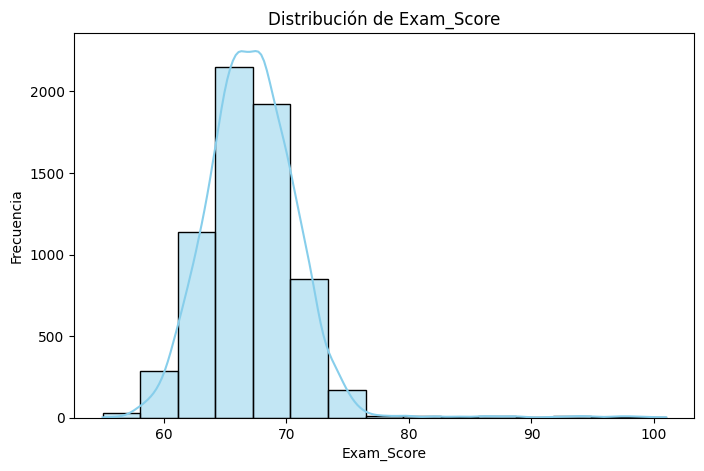

In [22]:
# Distribución del puntaje del examen
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], bins=15, kde=True, color='skyblue')
plt.title("Distribución de Exam_Score")
plt.xlabel("Exam_Score")
plt.ylabel("Frecuencia")
plt.show()

- Prepara la respuesta a: *“¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?”*  

- Muestra cuántas horas dedican los estudiantes al estudio.  
- Permite identificar patrones de estudio, concentración de estudiantes con pocas o muchas horas, y posibles sesgos que podrían afectar la relación con el puntaje del examen.

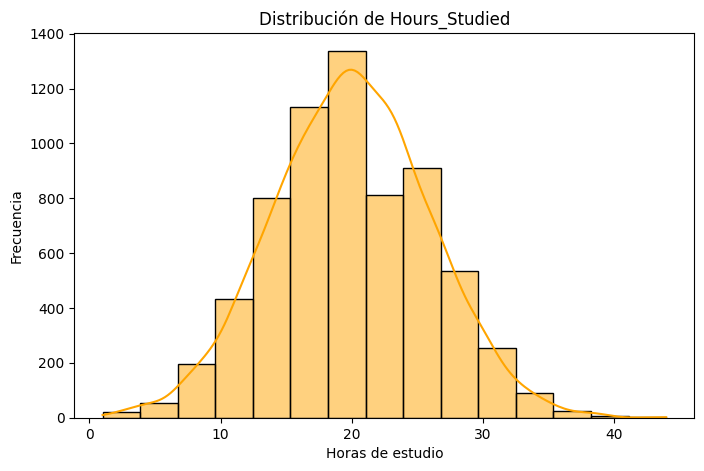

In [23]:
# Distribución de horas de estudio
plt.figure(figsize=(8,5))
sns.histplot(df['Hours_Studied'], bins=15, kde=True, color='orange')
plt.title("Distribución de Hours_Studied")
plt.xlabel("Horas de estudio")
plt.ylabel("Frecuencia")
plt.show()

- Prepara la respuesta a: *“¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?”*  

- Permite ver cómo se distribuye la asistencia de los estudiantes a clases.  
- Ayuda a identificar si hay estudiantes con asistencia muy baja o muy alta, lo cual es clave para analizar su impacto combinado con las horas de estudio sobre el rendimiento académico.

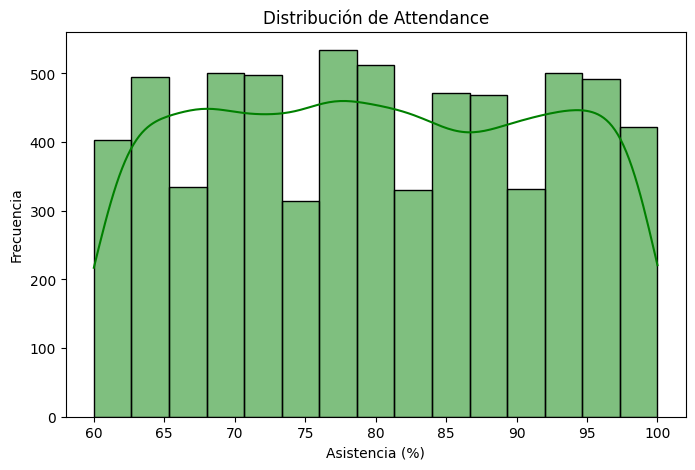

In [24]:
# Distribución de asistencia
plt.figure(figsize=(8,5))
sns.histplot(df['Attendance'], bins=15, kde=True, color='green')
plt.title("Distribución de Attendance")
plt.xlabel("Asistencia (%)")
plt.ylabel("Frecuencia")
plt.show()

**Visualizaciones Bivariadas**
Estas visualizaciones permiten explorar relaciones entre dos variables.  
- **Scatterplot Hours_Studied vs Exam_Score**: observa si más horas de estudio se traducen en mejores notas, considerando asistencia.  
- **Heatmap de correlaciones**: identifica qué variables están más relacionadas con `Exam_Score`.  

Nos ayuda a responder a la relación de horas de estudio, asistencia y tutoría con calificaciones; efecto de sueño y actividad física.



- Responde directamente a: *“¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?”*  

- Permite observar la relación entre las horas de estudio y el puntaje del examen.  
- El color según `Attendance` muestra cómo la asistencia potencia el efecto del estudio: estudiantes con mayor asistencia tienden a obtener mejores calificaciones para las mismas horas de estudio.

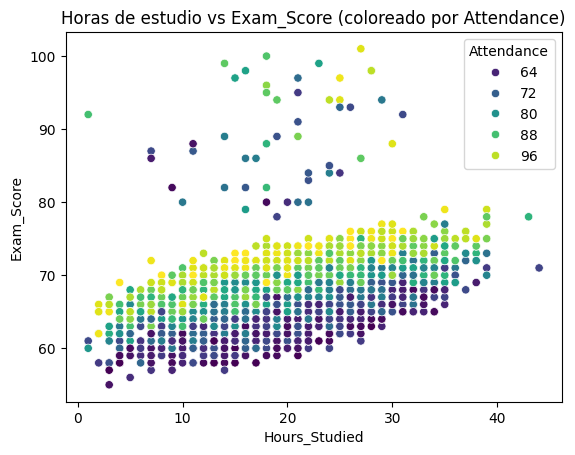

In [25]:
# Hours_Studied vs Exam_Score, coloreado por Attendance
sns.scatterplot(x='Hours_Studied', y='Exam_Score', hue='Attendance', palette='viridis', data=df)
plt.title("Horas de estudio vs Exam_Score (coloreado por Attendance)")
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.show()

- Ayuda a responder:  
  - *“¿Cómo se relacionan las horas de estudio, la asistencia y la tutoría con las calificaciones finales?”*  
  - *“¿De qué manera inciden variables como el sueño y la actividad física en el resultado del examen?”*  
  
- Permite identificar cuáles variables numéricas tienen mayor correlación con `Exam_Score`.  
- Por ejemplo, una correlación positiva alta con `Hours_Studied` o `Attendance` confirma su efecto en el rendimiento académico, mientras que otras variables como `Sleep_Hours` o `Physical_Activity` muestran efectos indirectos.

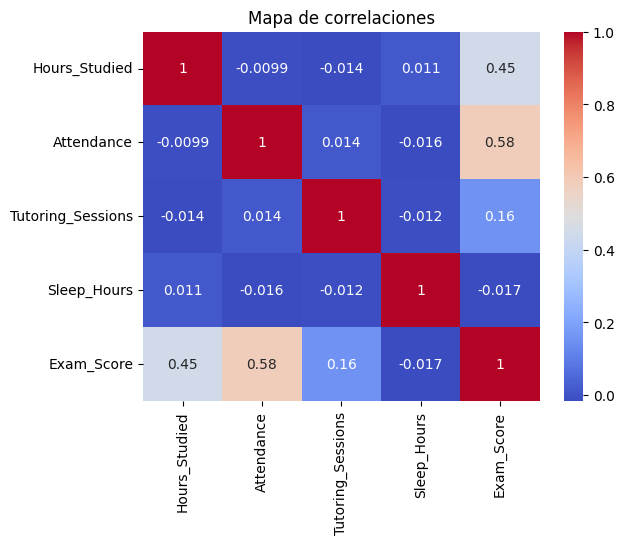

In [26]:
# Heatmap de correlación de variables numéricas clave
sns.heatmap(df[['Hours_Studied','Attendance','Tutoring_Sessions','Sleep_Hours','Exam_Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de correlaciones")
plt.show()


 Visualizaciones multivariadas (mínimo 3 variables)
 Estas permiten analizar efecto combinado de tres variables o más sobre el rendimiento.

1. Scatterplot multivariado: Hours_Studied, Tutoring_Sessions y Attendance vs Exam_Score.  
   - Evalúa la hipótesis de que las tutorías potencian el efecto de estudio y asistencia.  

2. Boxplot Parental_Education_Level y Family_Income: Exam_Score  
   - Muestra cómo el apoyo familiar y nivel socioeconómico influyen en las calificaciones.

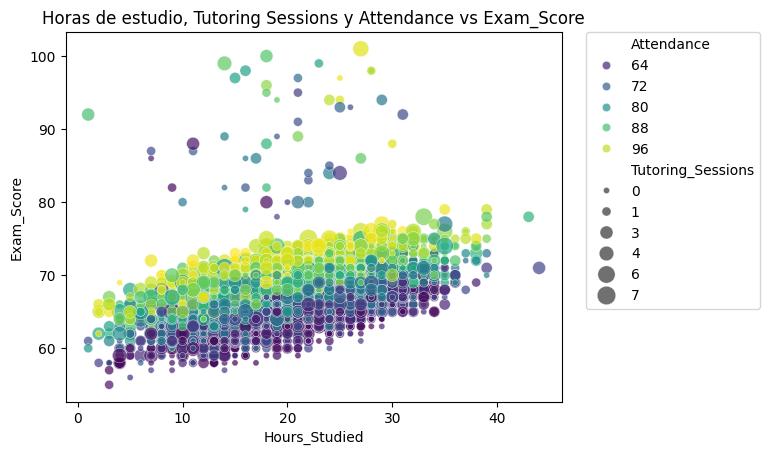

In [27]:
# Scatterplot multivariado
sns.scatterplot(x='Hours_Studied', y='Exam_Score', size='Tutoring_Sessions', hue='Attendance', data=df, palette='viridis', sizes=(20,200), alpha=0.7)
plt.title("Horas de estudio, Tutoring Sessions y Attendance vs Exam_Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
ruta = "/content/drive/MyDrive/Entrega n1/StudentPerformanceFactors.csv"
df = pd.read_csv(ruta)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [31]:
print("Duplicados:", df.duplicated().sum())
print("Nulos por columna:")
display(df.isnull().sum())
print("\nTipos de datos:")
display(df.dtypes)

Duplicados: 0
Nulos por columna:


,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Tipos de datos:


,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [32]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Desconocido')
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna('Desconocido')
df['Distance_from_Home'] = df['Distance_from_Home'].fillna('Desconocido')


In [33]:
print("Nulos por columna después de limpiar:")
print(df.isnull().sum())

Nulos por columna después de limpiar:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [34]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nDimensiones del nuevo dataset codificado:")
print(df_encoded.shape)



Dimensiones del nuevo dataset codificado:
(6607, 31)


In [35]:
from sklearn.feature_selection import SelectKBest, f_regression

# Separar variables independientes (X) y dependiente (y)
X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

# Aplicar SelectKBest para quedarnos con las 10 variables más relevantes
selector = SelectKBest(score_func=f_regression, k=10)
X_new = selector.fit_transform(X, y)

# Mostrar las 10 variables más importantes
selected_features = X.columns[selector.get_support()]
print("Características seleccionadas:\n", selected_features)


Características seleccionadas:
 Index(['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
       'Parental_Involvement_Low', 'Access_to_Resources_Low',
       'Learning_Disabilities_Yes', 'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Near'],
      dtype='object')


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Usamos solo las variables seleccionadas
X_selected = df_encoded[selected_features]
y = df_encoded['Exam_Score']

# Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

print("Modelo entrenado correctamente ✅")


Modelo entrenado correctamente ✅


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculamos métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Evaluación del modelo:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")


🔍 Evaluación del modelo:
Error Absoluto Medio (MAE): 0.99
Error Cuadrático Medio (MSE): 4.23
Coeficiente de Determinación (R²): 0.70


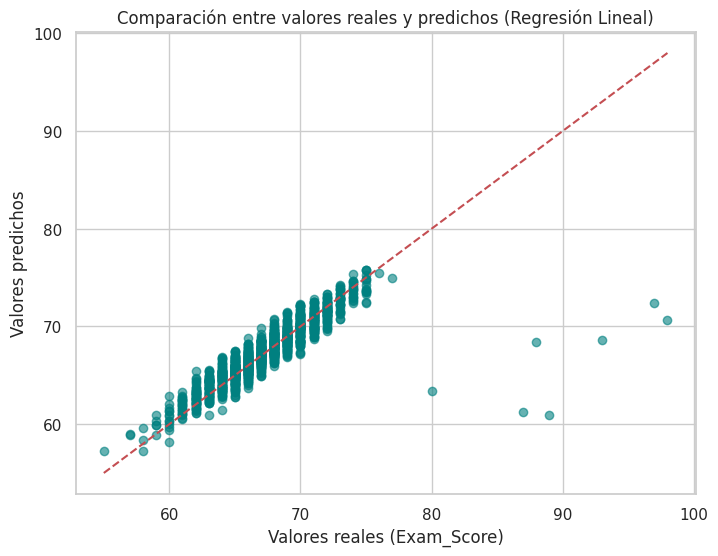

In [38]:
# Gráfico: valores reales vs predichos
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Valores reales (Exam_Score)")
plt.ylabel("Valores predichos")
plt.title("Comparación entre valores reales y predichos (Regresión Lineal)")
plt.show()


El modelo de regresión lineal desarrollado permitió predecir el puntaje de examen de los estudiantes a partir de un conjunto de variables académicas y personales.
A través del método SelectKBest, se seleccionaron las diez características más relevantes, entre ellas: las horas de estudio, la asistencia, los puntajes previos y la participación en tutorías.

El modelo fue entrenado con un conjunto de entrenamiento y validado con datos de prueba, obteniendo los siguientes resultados:

Error Absoluto Medio (MAE): 0.99

Error Cuadrático Medio (MSE): 4.23

Coeficiente de Determinación (R²): 0.70

Estos valores indican que el modelo logra una buena capacidad de predicción (70% de la variabilidad explicada), aunque aún existen factores externos o no medidos que podrían influir en el rendimiento académico.

El gráfico de valores reales vs. predichos muestra que la mayoría de los puntos se alinean con la diagonal, lo que refleja una correspondencia razonable entre las predicciones y los valores reales.

En conclusión, el análisis permitió identificar las variables más influyentes en el desempeño académico y construir un modelo predictivo eficaz, cumpliendo con los objetivos planteados en la entrega final del proyecto.


https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code